# Modelo Preditivo de Risco de Defasagem - Datathon Fase 5
Este notebook contém o modelo otimizado utilizando **Random Forest Classifier** para prever o risco de defasagem educacional (Target Binário).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

sns.set_theme(style="whitegrid")

## 1. Carregamento dos Dados

In [3]:
df = pd.read_csv('BASE DE DADOS PEDE 2024 - DATATHON - NORMALIZADA.txt', sep=';', encoding='utf-8')

## 2. Feature Engineering e Definição do Target
Transformamos o problema em uma classificação binária: Alunos com defasagem negativa (< 0) são marcados como **Risco (1)**.

In [4]:
# Criação do Target Binário
df['Target_Risco'] = (df['Defasagem'] < 0).astype(int)

# Seleção de Features (Removendo IDs e variáveis de vazamento)
features_num = ['Idade', 'IAA', 'IEG', 'IPS', 'IPP', 'IDA', 'Mat', 'Por']
features_cat = ['Gênero', 'Instituição de ensino']

X = df[features_num + features_cat]
y = df['Target_Risco']

## 3. Pipeline de Pré-processamento e Modelagem
Configuração dos hiperparâmetros para garantir estabilidade e evitar overfitting.

In [5]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, features_num),
        ('cat', categorical_transformer, features_cat)
    ])

# Random Forest com restrições de profundidade para reduzir variância
model_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        max_depth=7,
        min_samples_leaf=10,
        class_weight='balanced',
        random_state=42
    ))
])

## 4. Validação Cruzada Estratificada
Verificação da estabilidade do modelo (Meta: Desvio Padrão < 0.03).

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
model_rf.fit(X_train, y_train)
y_pred = model_rf.predict(X_test)
y_pred_proba = model_rf.predict_proba(X_test)[:, 1]

df_resultados = pd.DataFrame({
    'Realidade (0=Ok, 1=Risco)': y_test,
    'Previsao_Classe': y_pred,
    'Probabilidade_Risco (%)': np.round(y_pred_proba * 100, 2)
})

print("\n--- RELATÓRIO DE CLASSIFICAÇÃO TRADICIONAL ---")
print(classification_report(y_test, y_pred))
print(f"AUC ROC: {roc_auc_score(y_test, y_pred_proba):.4f}")

print("\n--- VISUALIZAÇÃO DAS PROBABILIDADES ---")
print("Top 10 Alunos com MAIOR Risco de Defasagem na base de teste:")
display(df_resultados.sort_values(by='Probabilidade_Risco (%)', ascending=False).head(10))

print("\nTop 10 Alunos com MENOR Risco de Defasagem na base de teste:")
display(df_resultados.sort_values(by='Probabilidade_Risco (%)', ascending=True).head(10))

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model_rf, X, y, cv=kfold, scoring='f1')

print("--- RESULTADOS DA VALIDAÇÃO CRUZADA ---")
for i, score in enumerate(scores):
    print(f"Fold {i+1}: {score * 100:.2f}%")

print(f"Acurácia Média: {scores.mean():.4f}")
print(f"Desvio Padrão: {scores.std():.4f}")


--- RELATÓRIO DE CLASSIFICAÇÃO TRADICIONAL ---
              precision    recall  f1-score   support

           0       0.66      0.62      0.64       403
           1       0.71      0.75      0.73       506

    accuracy                           0.69       909
   macro avg       0.68      0.68      0.68       909
weighted avg       0.69      0.69      0.69       909

AUC ROC: 0.7586

--- VISUALIZAÇÃO DAS PROBABILIDADES ---
Top 10 Alunos com MAIOR Risco de Defasagem na base de teste:


,"Realidade (0=Ok, 1=Risco)",Previsao_Classe,Probabilidade_Risco (%)
46,1,1,88.18
76,1,1,86.53
68,1,1,86.33
286,1,1,86.28
11,0,1,85.96
10,1,1,85.85
191,1,1,85.74
125,1,1,85.21
5,1,1,84.44
484,1,1,84.11



Top 10 Alunos com MENOR Risco de Defasagem na base de teste:


,"Realidade (0=Ok, 1=Risco)",Previsao_Classe,Probabilidade_Risco (%)
2958,0,0,1.94
2944,0,0,1.94
3008,0,0,1.94
2963,0,0,2.25
2956,0,0,2.52
2952,0,0,3.23
2984,0,0,3.23
3005,0,0,3.98
3010,0,0,3.98
2930,0,0,3.98


--- RESULTADOS DA VALIDAÇÃO CRUZADA ---
Fold 1: 75.00%
Fold 2: 77.52%
Fold 3: 75.81%
Fold 4: 75.00%
Fold 5: 77.01%
Acurácia Média: 0.7607
Desvio Padrão: 0.0103


## 5. Avaliação Final e Insights

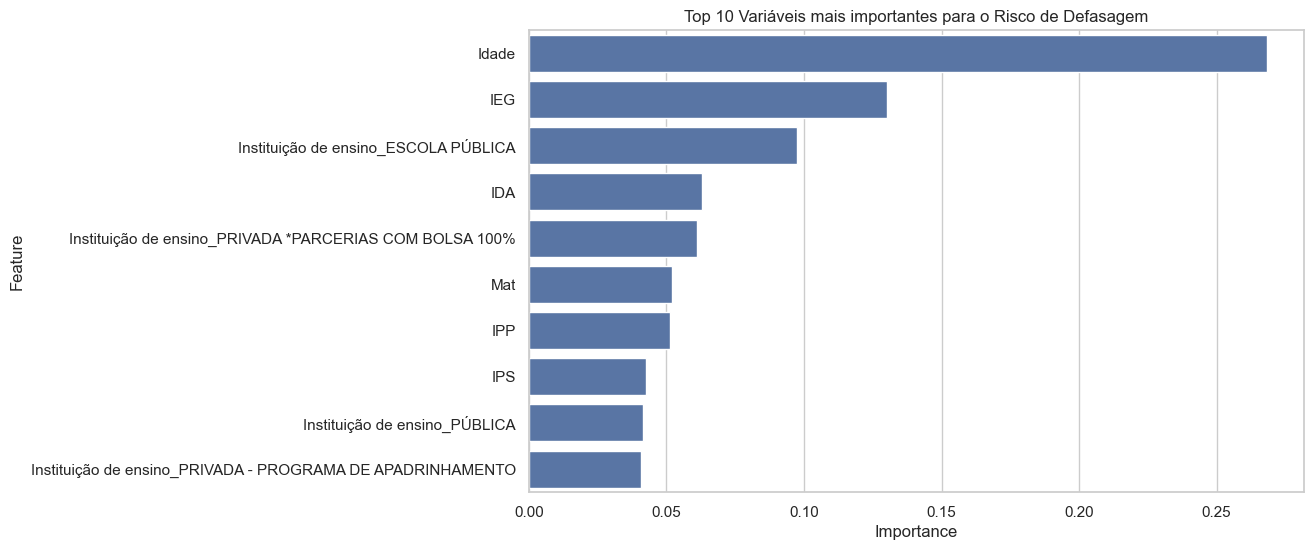

In [7]:
# Importância das Variáveis
classifier = model_rf.named_steps['classifier']
importances = classifier.feature_importances_
feature_names = features_num + list(model_rf.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(features_cat))

df_imp = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=df_imp.head(10))
plt.title('Top 10 Variáveis mais importantes para o Risco de Defasagem')
plt.show()

In [8]:
import joblib

# Salvando o modelo treinado em um arquivo .pkl (Pickle)
joblib.dump(model_rf, 'modelo_risco_defasagem.pkl')

['modelo_risco_defasagem.pkl']